In [1]:
import os
import PIL
import shutil
import numpy as np
import pathlib
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, save_model

In [3]:
dataset_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'

In [4]:
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

In [5]:
data_dir

'C:\\Users\\ROHIT VIRDI\\.keras\\datasets\\flower_photos'

In [6]:
data_dir = pathlib.Path(data_dir) / 'flower_photos'

In [7]:
data_dir

WindowsPath('C:/Users/ROHIT VIRDI/.keras/datasets/flower_photos/flower_photos')

In [9]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print('Total number of images: ', image_count)

Total number of images:  3670


In [10]:
batch_size = 32
image_height = 180
image_width  =180

In [11]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size=(image_height,image_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [12]:
import os

# print("Folders inside data_dir:")
# for item in os.listdir(data_dir):
#     print(item)

In [13]:
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (image_height,image_width),
    batch_size = batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [14]:
class_names = train_dataset.class_names
print("class names:", class_names)

class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [15]:
train_dataset = train_dataset.cache().shuffle(1000)
val_dataset = val_dataset.cache()

In [17]:
num_classes = len(class_names)
print('num classes:', num_classes)

num classes: 5


In [46]:
model = Sequential([
    layers.Rescaling(1./255, input_shape=(image_height, image_width,3)),
    layers.Conv2D(16,3, padding ='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding = 'same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(num_classes)
])

c:\Users\ROHIT VIRDI\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction = 'sum_over_batch_size'),
    metrics = ['accuracy']
)

In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [51]:
epochs = 20
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = epochs
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.3896 - loss: 1.4431 - val_accuracy: 0.5504 - val_loss: 1.1278
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.5923 - loss: 1.0160 - val_accuracy: 0.5763 - val_loss: 1.0854
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - accuracy: 0.6761 - loss: 0.8542 - val_accuracy: 0.6226 - val_loss: 0.9415
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.7718 - loss: 0.6323 - val_accuracy: 0.6444 - val_loss: 0.9817
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.8416 - loss: 0.4336 - val_accuracy: 0.6362 - val_loss: 1.1054
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.9152 - loss: 0.2524 - val_accuracy: 0.6580 - val_loss: 1.2103
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.9479 - loss: 0.1652 - val_accuracy: 0.6226 - val_loss: 1.4218
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.9683 - loss: 0.1073 - val_accu

## Training Complete

In [52]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

In [53]:
loss = history.history['loss']
val_loss = history.history['val_loss']

In [54]:
epochs_range = range(epochs)

Text(0.5, 1.0, 'Training and Validation Accuracy')

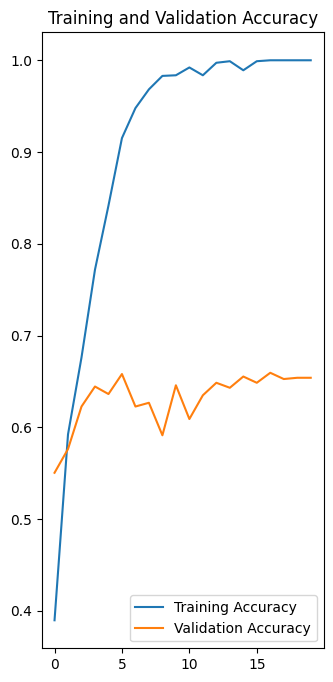

In [62]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label = 'Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

Text(0.5, 1.0, 'Training and Validation Loss')

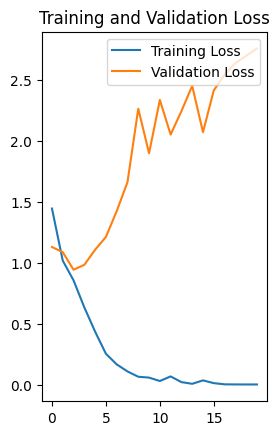

In [64]:
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label = 'Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

In [65]:
save_model(model, 'flower_model_trained.hdf5')
print('model saved')

model saved
